# Comprobación del entorno

**Módulo:** Depuración, Limpieza y Clasificación de Datos (5109)
**Curso académico:** 2026-2027

Ejecuta las celdas en orden (`Mayús + Intro`) o pulsa **Run All**. Si todo sale bien, tu entorno está listo.
Si algo falla, consulta el apartado *Solución de problemas* de `INSTALACION.md`.

## 1. ¿Qué Python estoy usando?

La ruta debe terminar en `DLCD\.venv\Scripts\python.exe` (Windows) o `DLCD/.venv/bin/python` (Linux/macOS).

In [4]:
import sys
from pathlib import Path

print("Versión de Python:", sys.version.split()[0])
print("Intérprete:       ", sys.executable)

en_venv = ".venv" in Path(sys.executable).parts
print()
print("OK: estás usando el entorno .venv del repositorio" if en_venv
      else "ATENCIÓN: no estás usando el kernel .venv. Cámbialo arriba a la derecha (Select Kernel).")

Versión de Python: 3.12.10
Intérprete:        c:\Users\aas19\Documents\GitHub\DLCD\.venv\Scripts\python.exe

OK: estás usando el entorno .venv del repositorio


## 2. Librerías del curso

In [5]:
from importlib import import_module
import warnings
warnings.filterwarnings("ignore")

librerias = [
    ("numpy", "numpy"), ("pandas", "pandas"), ("pyarrow", "pyarrow"), ("openpyxl", "openpyxl"),
    ("lxml", "lxml"), ("datasets", "datasets"), ("kagglehub", "kagglehub"),
    ("matplotlib", "matplotlib"), ("seaborn", "seaborn"), ("missingno", "missingno"),
    ("ydata_profiling", "ydata-profiling"),
    ("scipy", "scipy"), ("statsmodels", "statsmodels"), ("pingouin", "pingouin"),
    ("sklearn", "scikit-learn"), ("imblearn", "imbalanced-learn"), ("ipywidgets", "ipywidgets"),
]

faltan = []
for modulo, nombre in librerias:
    try:
        m = import_module(modulo)
        print(f"  OK     {nombre:<18} {getattr(m, '__version__', '')}")
    except ImportError:
        print(f"  FALTA  {nombre}")
        faltan.append(nombre)

print("-" * 40)
print("Todo correcto." if not faltan else "Faltan librerías: cierra VS Code, ejecuta `uv sync` en la carpeta DLCD y vuelve a abrirlo.")

  OK     numpy              2.3.5
  OK     pandas             2.3.3
  OK     pyarrow            25.0.1
  OK     openpyxl           3.1.5
  OK     lxml               6.1.3
  OK     datasets           5.0.1
  OK     kagglehub          1.0.2
  OK     matplotlib         3.10.0
  OK     seaborn            0.13.2
  OK     missingno          0.5.2
  OK     ydata-profiling    4.18.4
  OK     scipy              1.16.3
  OK     statsmodels        0.15.0
  OK     pingouin           0.6.1
  OK     scikit-learn       1.9.1
  OK     imbalanced-learn   0.14.2
  OK     ipywidgets         8.1.9
----------------------------------------
Todo correcto.


## 3. Prueba rápida: datos y gráficos

Esta celda descarga un conjunto de datos de ejemplo, así que necesita conexión a Internet.

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Valores nulos por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


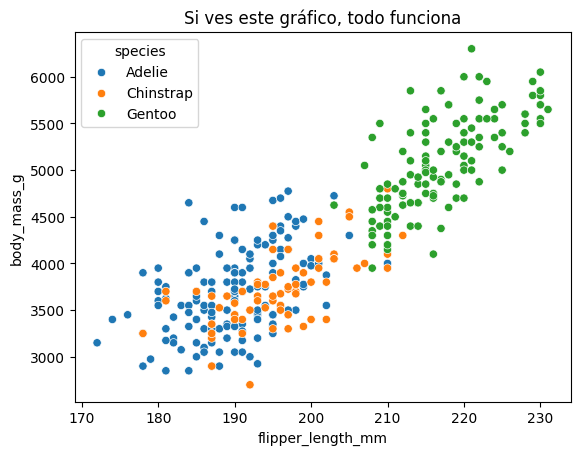

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins")
display(penguins.head())
print("Valores nulos por columna:")
print(penguins.isna().sum())

sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g", hue="species")
plt.title("Si ves este gráfico, todo funciona")
plt.show()